In [2]:
%load_ext autoreload
%autoreload 2

import os, sys, re
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchdiffeq import odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch


# main_dir = "/home/wz369/rds/hpc-work/PINN_dynamics"
main_dir = "/Users/weizhongzheng/Documents/python_project/PINN_dynamics/"
os.chdir(main_dir)

In [3]:
import palantir
# import cellrank as cr
import scvelo as scv

In [4]:
sc.settings.set_figure_params(frameon=False, dpi=50, figsize=(3,3))

# load data

In [5]:
# # load dataset

adata = sc.read_h5ad(f'data/ery_mk_Aug1.h5ad')
tompos = sc.read_h5ad(f'data/tom_pos.h5ad')

In [8]:
adata.obs.query("`anno_man` == 'HSC'").sort_values('timepoint_tx_days')['timepoint_tx_days'].value_counts()

timepoint_tx_days
269    1170
112     704
161     518
76      498
27      386
49      281
7       130
3       105
12       67
Name: count, dtype: int64

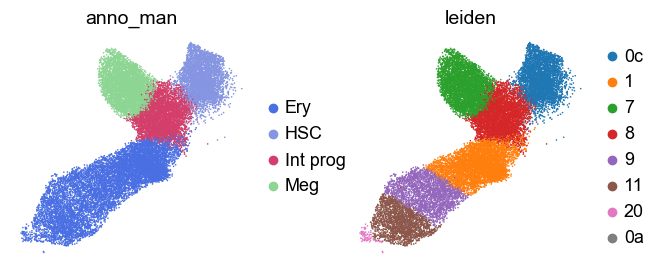

In [9]:
sc.pl.umap(adata, color=['anno_man','leiden'])

In [12]:
tompos.obs.query("`anno_man` == 'HSC'").sort_values('timepoint_tx_days')['timepoint_tx_days'].value_counts()

timepoint_tx_days
269    1943
112    1178
161     871
76      791
27      581
49      491
7       177
3       138
12       94
Name: count, dtype: int64

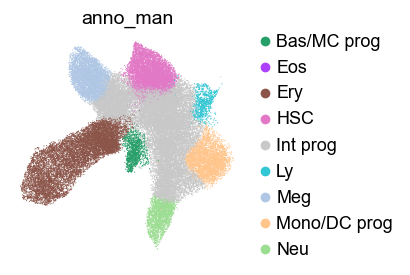

In [11]:
sc.pl.umap(tompos, color=['anno_man'])

# load density transport results

In [18]:
from PINN.models import DT_analysis

## Exp configs

In [35]:
def check_non_zero_prop(TM):
    "For transport matrix at given time, check non zeros transport"

    ncell = TM.shape[0]
    TM_flat = TM.reshape(ncell,-1)
    nz =  np.sum(TM_flat.sum(axis=1) != 0) # count non zero cells

    return nz / ncell


In [ ]:
# find all config files
config_dir = "logs/ery_mk_Aug1_multiscaled_n6/pde_params_tsense/"
configs = [file for file in os.listdir(config_dir) if file.endswith('.json')]

# load config for different runs
config_dict = {}
for js in configs:
    version = js.split("_")[0][1:] # after V
    config = PINN.ExperimentConfig(os.path.join(config_dir, js))
    config.from_json(os.path.abspath(os.path.join(config_dir, js)), main_dir)
    config_dict[version] = config

In [ ]:
v = '2'
DT = DT_analysis(adata, f"results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_{v}/Density_transport", 
                    "HSC")

dict_keys(['4-9', '24-46', '73-109', '109-158', '9-24', '0-4', '46-73'])

# aggregated density

In [ ]:
celltypes = ['Ery','HSC','Int prog','Meg']

ct_prop = DT.density_by_celltype_step(celltypes)
agg_density = DT.density_by_celltype_step(celltypes, step=-1, norm=False)

In [ ]:
result_dir = 'results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2'

In [ ]:
days = ['0-4', '4-9',  '9-24', '24-46', '46-73']

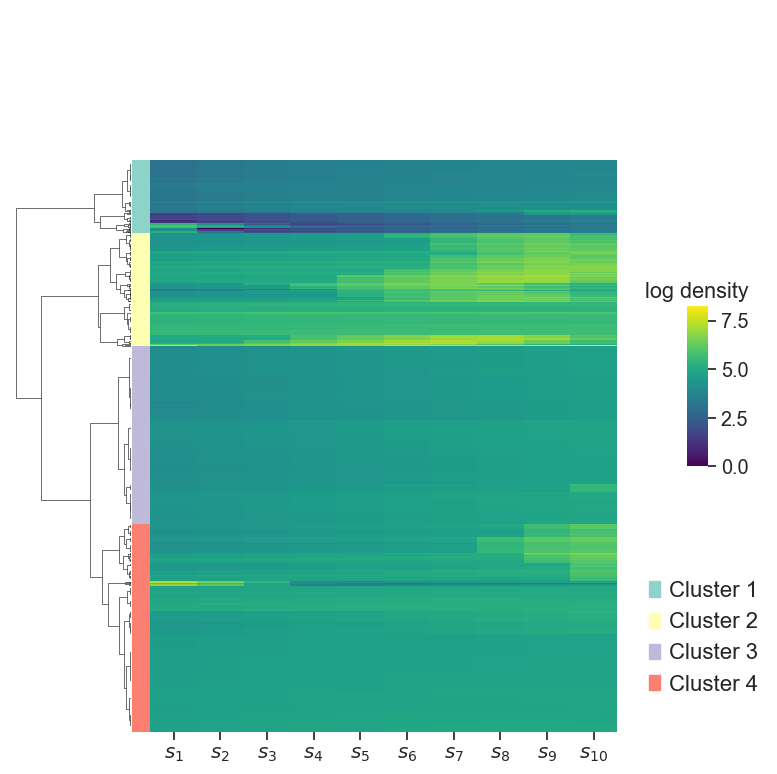

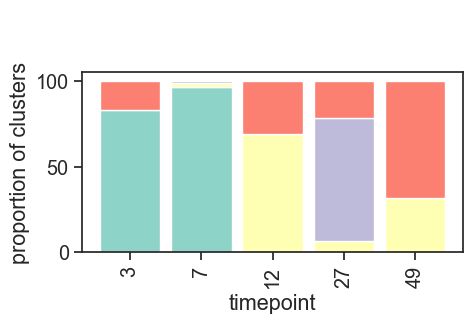

In [ ]:
n_clusters=4
log_normalize=True
data = 'norm' #['raw','norm']

tick_labels = [r"$s_1$", r"$s_2$", r"$s_3$", r"$s_4$", r"$s_5$",
               r"$s_6$", r"$s_7$", r"$s_8$", r"$s_9$", r"$s_{10}$"]

result_dir = 'results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2'



laststep_TM = []
for time in days:
    if data =='raw':
        TM = DT.TM_dict[time]
    else:
        TM = DT.TM_norm_dict[time]
    laststep_TM.append(TM[:,-1])

laststep_TM = np.concatenate(laststep_TM, axis=0)

clusters, row_linkage, reorded_i = DT.hierarchical_clustering(density_matrix=laststep_TM,
                                                    n_clusters=n_clusters, 
                                                    log_normalize=log_normalize)

g = DT.clustermap(  
                density_matrix = laststep_TM,
                clusters = clusters, 
                row_linkage = row_linkage, 
                celltypes = tick_labels,
                cmap = 'viridis',
                cbar_pos = [1, 0.4, 0.03,0.2],
                figsize = (7,8),
                log_normalize=True
                )

log_name = ['', 'log '][log_normalize]

g.savefig(os.path.join(result_dir, f'{data}_laststep_density_clustermap_c{n_clusters}{log_name}.pdf'), 
          dpi=600, transparent=True)



cellbarcodes = np.concatenate([DT.cb_dict[d] for d in days])
fig, ax = DT.cluster_proportion(clusters, cellbarcodes)
fig.savefig(os.path.join(result_dir, f'{data}_laststep_transportcluster_prop_c{n_clusters}{log_name}.pdf'), 
          dpi=600, transparent=True)